In [5]:
import re
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, 
                             roc_curve, auc)
from imblearn.over_sampling import SMOTE

# Robust PII regexes for Sinhala/English
EMAIL_RE = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", re.UNICODE)
NIC_RE = re.compile(r"(?<!\d)(\d{9}[VvXx]|\d{12})(?!\d)")
PHONE_RE = re.compile(r"(?x)(?<!\d)((?:(?:\+94)[\s-]*\d{2,3}(?:[\s-]*\d){2,7})|(?:0\d{2,3}(?:[\s-]*\d){2,7}))(?!\d)", re.UNICODE)

def _clean_phone(s: str) -> str:
    return re.sub(r"[\s\-]", "", s)

def detect_structured_pii(text: str) -> Dict[str, List[str]]:
    emails = EMAIL_RE.findall(text)
    nics = NIC_RE.findall(text)
    raw_phones = PHONE_RE.findall(text)
    phones = [_clean_phone(p[0] if isinstance(p, tuple) else p) for p in raw_phones]
    return {"emails": emails, "nics": nics, "phones": phones}

def extract_address_text(text: str) -> str:
    en_pattern = r"(No\s?\d+[\w\s,]+(?:Rd|Road|Street|Lane|Ave|Avenue|Town|Colombo|Galle|Kandy|Jaffna)[\w\s,.]*)"
    si_pattern = r"(ලිපිනය\s?[\w\s,/-]+(?:පාර|වත්ත|මාවත|නගරය|කොළඹ|මහනුවර|ගාල්ල)[\w\s,.]*)"
    en_match = re.search(en_pattern, text, re.IGNORECASE)
    si_match = re.search(si_pattern, text)
    if en_match: return en_match.group(0).strip()
    if si_match: return si_match.group(0).strip()
    return "Address detected by model, but specific string could not be parsed."

In [6]:
# 1. Load dataset
DATASET_PATH = '/kaggle/input/datasets/sudda02/new-pii-1000/combined_dataset.csv'
df = pd.read_csv(DATASET_PATH)
df['text'] = df['text'].fillna('')

# 2. Vectorization
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_tfidf = vectorizer.fit_transform(df['text'])
y = df['physical_address']

# 3. Balance the Dataset using SMOTE (Synthetic Augmentation)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y)
print(f"Balanced Dataset Size: {X_resampled.shape[0]} samples")

# 4. Random Forest (Ensemble Model to prevent Overfitting)
# n_estimators=100 and max_depth=20 help control model complexity
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)

# 5. Stratified K-Fold Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("--- CROSS-VALIDATION (Random Forest) ---")
cv_scores = cross_val_score(rf_model, X_resampled, y_resampled, cv=skf, scoring='f1')
print(f"Mean F1-Score: {cv_scores.mean():.4f}")

# 6. Final Train
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
rf_model.fit(X_train, y_train)

# Save components
joblib.dump(rf_model, 'address_model_rf.pkl')
joblib.dump(vectorizer, 'vectorizer_rf.pkl')

Balanced Dataset Size: 1480 samples
--- CROSS-VALIDATION (Random Forest) ---
Mean F1-Score: 0.9918


['vectorizer_rf.pkl']


RANDOM FOREST EVALUATION
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       142
           1       1.00      0.98      0.99       154

    accuracy                           0.99       296
   macro avg       0.99      0.99      0.99       296
weighted avg       0.99      0.99      0.99       296



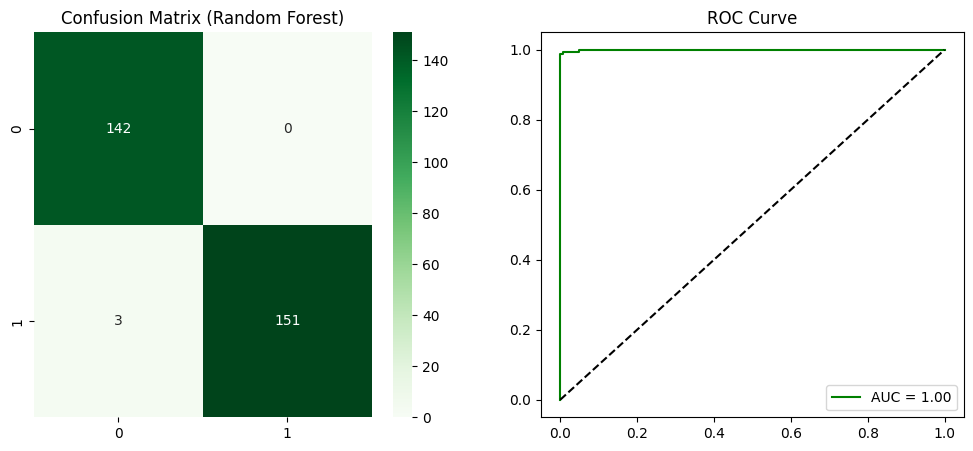


=== RANDOM FOREST PII DETECTOR ===



Enter message to analyze (or 'exit'):  Client info: Address: No 348, Lotus Rd, Negombo, NIC: 198826456565, Email: info6791@company.lk.



------------------------------
NIC:     ['198826456565']
Emails:  ['info6791@company.lk']
Phones:  None
Address: No 348, Lotus Rd, Negombo, NIC
------------------------------


In [ ]:
# 1. Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# 2. Visual Evaluation Display (One-time)
print("\n" + "="*40)
print("RANDOM FOREST EVALUATION")
print("="*40)
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix (Random Forest)')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax[1].plot(fpr, tpr, color='green', label=f'AUC = {auc(fpr, tpr):.2f}')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('ROC Curve')
ax[1].legend()
plt.show()

# 3. Interface
def pii_detector_interface():
    print("\n=== RANDOM FOREST PII DETECTOR ===")
    while True:
        user_input = input("\nEnter message to analyze (or 'exit'): ")
        if user_input.lower() == 'exit': break
        
        reg_res = detect_structured_pii(user_input)
        tfidf_input = vectorizer.transform([user_input])
        address_detected = rf_model.predict(tfidf_input)[0]
        
        print("\n" + "-"*30)
        print(f"NIC:     {reg_res['nics'] if reg_res['nics'] else 'None'}")
        print(f"Emails:  {reg_res['emails'] if reg_res['emails'] else 'None'}")
        print(f"Phones:  {reg_res['phones'] if reg_res['phones'] else 'None'}")
        print(f"Address: {extract_address_text(user_input) if address_detected else 'None Detected'}")
        print("-"*30)

pii_detector_interface()